## 머신러닝 프로젝트

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 강의노트입니다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전합니다.

## 환경설정

This project requires Python 3.10 or above:

In [1]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [2]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Let's define the default font sizes, to plot pretty figures:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

**기본 라이브러리**

In [4]:
import numpy as np
import pandas as pd

## 머신러닝 모델 훈련용 데이터

### 데이터 기초 정보

1990년도에 시행된 미국 캘리포니아 주의 20,640개 구역별 주택 가격 데이터는
위 엑셀 파일 그림의 1번 행에 표시된 대로
경도, 위도, 주택 건물 중위연령, 총 방 수, 총 침실 수, 인구, 가구 수, 중위소득, 주택 중위가격, 해안 근접도
등 총 10개의 **특성**<font size='2'>feature</font>을 포함한다. 
참고로 통계 분야에서는 특성을 변수 또는 변인 등으로 부르지만 머신러닝 분야에서는 특성이라 부르는 게 일반적이다.

### 머신러닝 훈련 모델 선택

구역별 주택 중위가격을 타깃으로 예측하는 시스템에 활용될
**회귀 모델**을 훈련시키고자 한다.
훈련시킬 모델의 특성은 다음과 같다.

* 지도학습: 구역별 주택 중위가격을 타깃, 즉
    최대한 정확하게 예측해야 하는 목표로 지정한다. 

* 회귀: 주택 중위가격, 즉 이산형 값이 아닌 연속형 값을 예측한다. 
    보다 세분화하면 다중 회귀이자 단변량 회귀 모델이다.
  * 다중 회귀<font size="2">multiple regression</font>: 구역별로 여러 특성을 주택 가격 예측에 사용
  * 단변량 회귀<font size="2">univariate regression</font>: 구역별로 한 종류의 값만 예측

* 배치 학습: 빠르게 변하는 데이터에 적응할 필요가 없으며, 데이터셋의 크기도 충분히 작기에
    데이터셋 전체를 대상으로 훈련을 진행한다.

### 데이터 구하기

캘리포니아 주택 가격 데이터는 매우 유명하여 많은 공개 저장소에서 다운로드할 수 있다.
여기서는 개인 깃허브 리포지토리에 압축파일로 저장한 파일을 다운로드해서 사용한다.

아래 코드의 `load_housing_data()` 함수는
지정된 깃허브 리포지토리에 tgz 형식의 압축 파일로 저장되어 있는
캘리포니아 주택 가격 데이터를 다운로드한 후에 
Pandas 데이터프레임으로 변환하여 반환한다.
따라서 `housing` 변수는 캘리포니아 주택 가격 데이터를 담고 있는 데이터프레임을 가리킨다.

**데이터셋 다운로드**

In [5]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

## 데이터셋 탐색

데이터 탐색은 훈련을 시작하기 전에 주어진 데이터셋의
다양한 특성을 대략적으로 살펴보는 과정이다.
데이터 시각화는 데이터 탐색을 위한 주요 기법 중의 하나이다.
먼저 데이터프레임의 메서드를 활용한 데이터 탐색을 알아본다.

### 데이터프레임 활용

In [6]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [7]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


### 범주형 대 수치형

**범주형 특성**

'해안 근접도'는 5개의 범주로 구분된다.
데이터프레임의 `valule_counts()` 메서드는 사용된 특성값과 각각의 특성값이 사용된 횟수를 확인해준다.

In [8]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

각 특성값의 의미는 다음과 같다.

| 특성값 | 설명 |
| :--- | :--- |
| <1H OCEAN | 해안에서 1시간 이내 |
| INLAND | 내륙 |
| NEAR OCEAN | 해안 근처 |
| NEAR BAY | 샌프란시스코의 Bay Area 구역 |
| ISLAND | 섬  |

**수치형 특성**

범주형 특성과는 다르게 수치형 특성은 정수 또는 부동소수점으로 구성된 특성이며, 
평균값, 표준편차, 사분범위 등 수치형 특성들의 정보를 확인할 수 있다.
해안 근접도를 제외한 나머지 특성들 모두 수치형 특성이다.

In [9]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


수치형 특성별로 히스토그램을 통해 다음 정보를 얻을 수 있다.

- 각 특성마다 사용되는 단위와 스케일이 다르다. 1 단위부터 만 단위까지 다양하다.
- 일부 특성은 한쪽으로 치우쳐저 있다. 
    예를 들어 `total_rooms`, `total_bedrooms`, `population`, `households` 등의 특성값들이 오른쪽 꼬리를 길게 갖는다.
- 일부 특성은 값을 제한한 것으로 보인다. 
 예를 들어 `housing_median_age`, `median_house_value` 등의 특성값 상한값이 임의로 지정되어 잘린 것처럼 보인다.

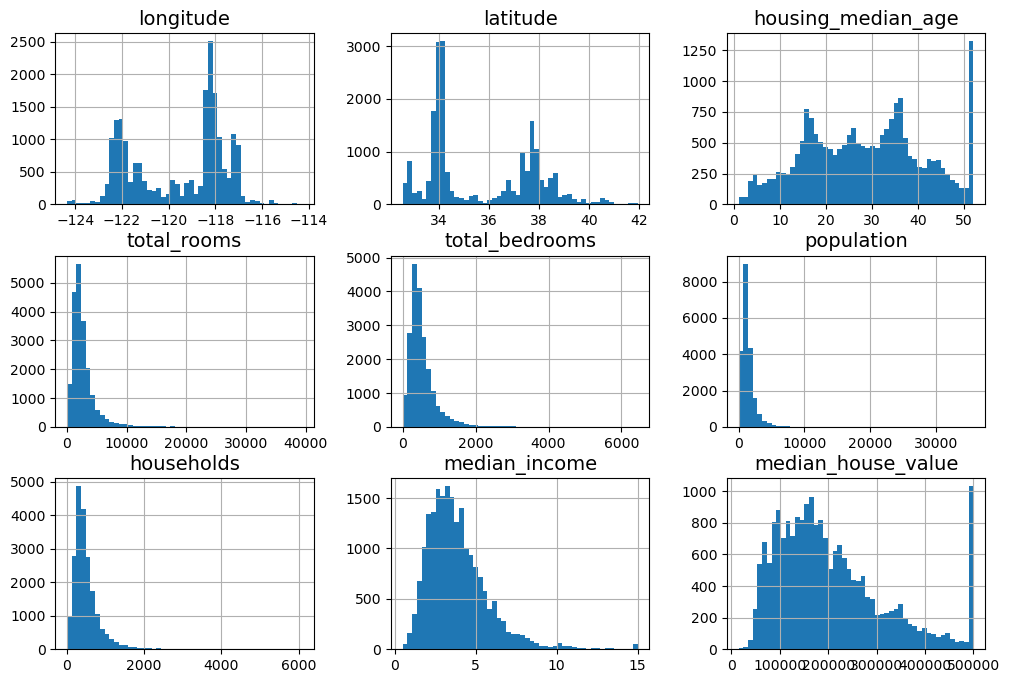

In [10]:
housing_full.hist(bins=50, figsize=(12, 8))

plt.show()

## 훈련셋과 테스트셋

모델 훈련을 시작하기 전에 전체 데이터셋을 보통 **훈련셋**<font size='2'>training set</font>과
**테스트셋**<font size='2'>test set</font>으로 나눈다.
테스트셋은 훈련 과정중에 전혀 사용되지 않으며 보통 전체 데이터셋의 최대 10~20% 정도로
선택하며, 전체 데이터셋의 크기에 따라 테스트셋의 크기가 너무 크지 않게 
비율을 적절히 조절한다.

- 훈련셋: 머신러닝 모델 훈련에 사용되는 데이터셋을 가리킨다.
    이후에 실제 모델 훈련을 시작하기 전에 다시 입력 데이터셋과 타깃셋으로 특성을 기준으로 쪼개진다.
- 테스트셋: 훈련을 마친 모델의 성능을 평가하기 위해 사용하는 데이터셋이다.
    훈련 과정에서는 어떤 형식으로든 절대로 활용하지 않는다.
    훈련될 모델을 이용하여 테스트되기 이전에 훈련세처럼 
    동일한 기준으로 입력 데이터셋과 타깃셋으로 나뉘어진다.

### 무작위 샘플링

전체 데이터에서 무작위로 샘플을 추출하는 방식이다.
데이터셋이 매우 크다면 모집단을 잘 대표할 수 있지만, 그렇지 않을 경우 샘플링 편향이 발생해 특정 특징을 가진 데이터가 과하게 많거나 적게 추출될 위험이 있다.

In [11]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

### 계층 샘플링

먼저 구역별 중위소득 특성을 대상으로 히스토그램을 그려보면
대부분 구역의 중위소득이 1.5 ~ 6.0, 즉 15,000에서 60,000 달러 사이인 것을 알 수 있다.

<Axes: >

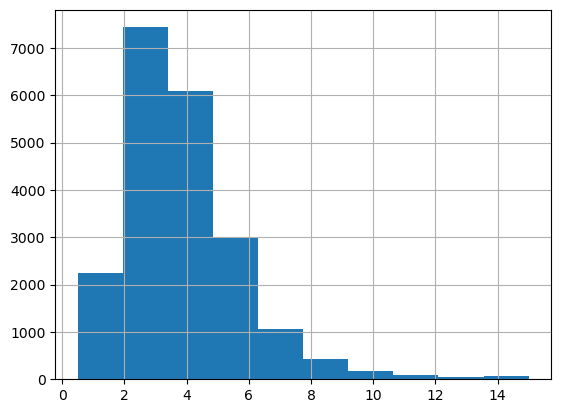

In [12]:
housing_full['median_income'].hist()

따라서 중위소득 구간을 아래처럼 5개로 구분한 다음에 계층 샘플링을 이용하여
훈련셋과 테스트셋을 구분하면 좋을 것 같아 보인다.

In [13]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

먼저 언급된 5 개의 구간으로 구분하는 `"income_cat"` 특성을 추가한다.
`pd.cut()` 함수는 특성과 구간 구분이 주어지면 각 구간에 해당하는 특성값들에 지정된 레이블을 할당하는
형식으로 새로운 특성값들을 만들어 낸다.

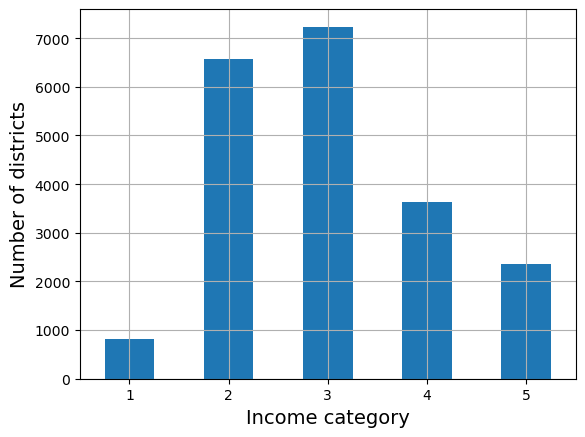

In [14]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

이제 `"income_cat"` 특성에 사용된 값들의 분포 비율을 반영하면서 
훈련셋과 테스트셋을 8대 2로 나눈다.
사이킷런의 `train_test_split()` 함수는 데이터프레임에 속한 샘플을
지정된 비율로 두 개의 데이터프레임으로 나눌 때
계층 샘플링을 지원한다.

In [15]:
strat_train_set, strat_test_set = train_test_split(
    housing_full, test_size=0.2, stratify=housing_full["income_cat"],
    random_state=42)

### 무작위 샘플링 대 계층 샘플링

계층 샘플링이 무작위 샘플링보다 계층별 샘플의 비율을 훨씬 잘 유지함을 아래 표가 확인해준다.
`Strat. Error %`와 `Rand. Error %`는 모집단에서의 계층별 빈도 기준 표본에서의 계층별 빈도의
변화율을 가리킨다.
계층 샘플링이 변화율이 무작위 샘플링의 변화율보다 작음에 주목한다.

In [16]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing_full),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()

compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] / 
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


**`income_cat` 특성 삭제**

해당 특성은 계층 샘플링을 위한 용도로만 사용되기에 더 이상 필요 없어서 삭제한다.

In [17]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## 훈련셋 살펴보기

데이터 살펴보기는 지금까지와는 달리 훈련셋만을 대상으로 진행한다.
훈련셋은 캘리포니아 전체 데이터셋에서 앞서 설명한 계층 샘플링을 이용하여 생성되었다고 가정한다.
훈련셋의 크기는 전체 데이터셋의 크기인 20,640의 80%인 16,512다.

**주의사항**

앞서 언급한 대로 훈련이 완료된 모델의 성능 평가용도로만 사용된다.

아래 코드는 `housing` 변수가 가리키는 데이터셋 객체를 전체 데이터셋에서
계층 샘플링을 이용하여 생성된 훈련셋의 복사본으로 변경한다.

In [18]:
housing = strat_train_set.copy()

훈련셋의 크기는 전체 데이터셋의 크기인 20,640의 80%인 16,512다.

In [19]:
housing.shape

(16512, 10)

### 훈련셋 시각화

훈련셋에 포함된 16,512개 구역의 
경도와 위도 정보를 이용하여 구역 정보를 산포도로 나타내면 인구의 밀집 정도를 확인할 수 있다. 
예를 들어, 샌프란시스코의 Bay Area, LA, 샌디에고 등 유명 대도시의 특정 구역이 높은 인구 밀도를 갖는다.

데이터프레임의 `plot()` 메서드는 다양한 종류의 그래프를 그린다.
`kind` 매개변수의 키워드 인자를 `"scatter"`로 지정하면 산점도를 그린다.
이외에 다양한 키워드 인자를 그래프 옵션으로 지정할 수 있다.
예를 들어 구역의 주택 중위가격을 색상으로, 
인구밀도는 원의 크기로 활용하면
인구 밀도가 높은 유명 대도시의 특정 구역에 위치한
주택 가격이 높다는 일반적인 사실 또한 쉽게 확인된다.

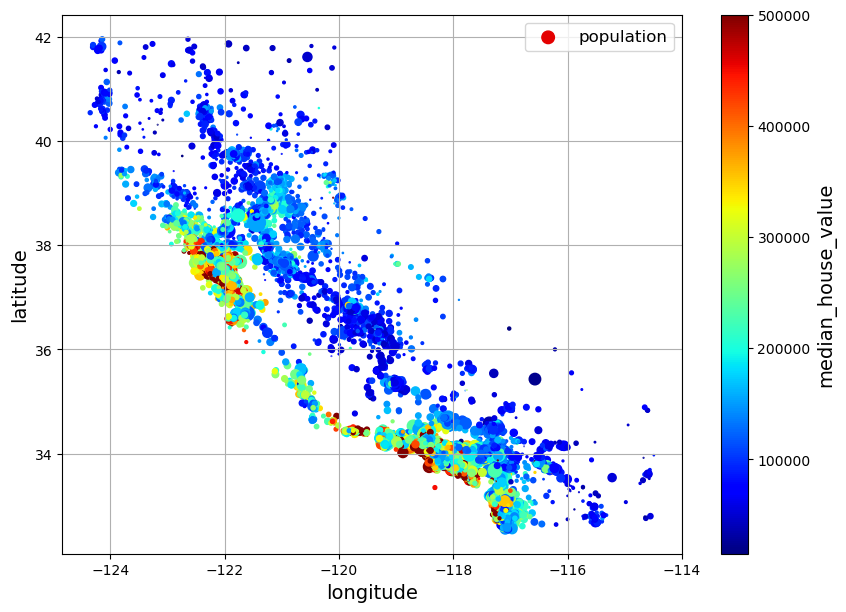

In [20]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
            s=housing["population"] / 100, label="population",
            c="median_house_value", cmap="jet", colorbar=True,
            legend=True, sharex=False, figsize=(10, 7))

plt.show()

### 피어슨 상관관계

앞으로 훈련시킬 모델은 어떤 구역의 중위 주택 가격을 제외한 다른 특성이 주어졌을 때
해당 구역의 중위 주택 가격을 예측해야 한다.
따라서 중위 주택 가격과 상관관계가 높은 특성을 미리 확인해보아야 한다.

특성들 사이의 선형 상관관계를 피어슨 상관계수로 계산한다.
단, 수치형 특성만 대상으로 한다.

In [21]:
corr_matrix = housing.corr(numeric_only=True)

Seaborn 라이브러리의 히트맵 함수를 이용하여 상관관계의 강도를 시각화해본다.

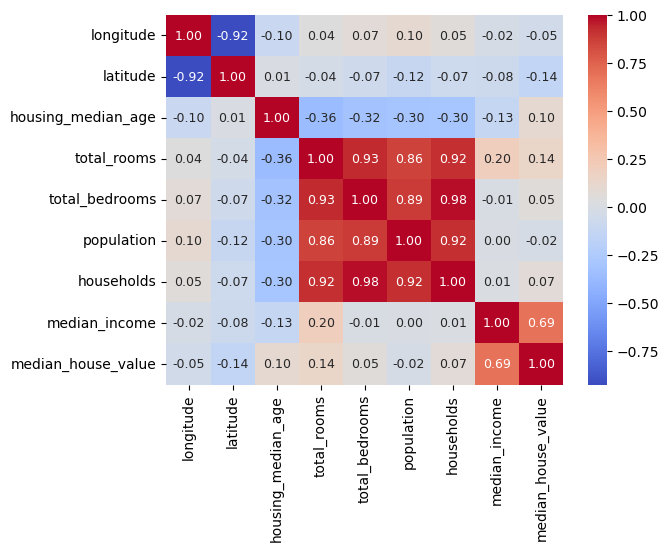

In [22]:
import seaborn as sns
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            annot_kws={"size": 9})
plt.show()

주택 중위가격과 중위소득의 상관계수가 0.68로 상당히 높다.
이는 중위소득이 올라가면 주택 중위가격도 상승하는 경향이 꽤 강하게 있음을 의미한다.
아래 산점도가 이 사실을 잘 확인시켜준다. 

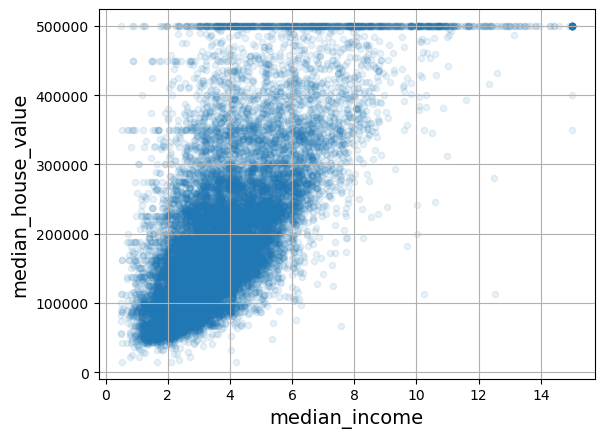

In [23]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)

plt.show()

## 타깃 대 입력 데이터셋

지도학습 방식으로 중위 주택 가격을 예측하는 모델을 훈련시키려면
훈련셋을 타깃셋과 입력 데이터셋으로 분리해야 한다.
입력 데이터셋 또한 일반적으로 훈련셋으로 불린다.

In [24]:
# 훈련셋 (입력 데이터셋)
housing = strat_train_set.drop("median_house_value", axis=1)

# 타깃셋
housing_labels = strat_train_set["median_house_value"].copy()

**참고:**

- 이전 셀의 코드는 `housing` 데이터프레임 새롭게 정의한다.
    이렇게 하는 이유는 입력 데이터셋과 타깃셋을 구분하는 과정을 포함하여 앞으로 설명할 모든 전처리 과정을 한 번에 처리할 자동화된 '변환 파이프라인'을 구축하기 위함이다.

- `strat_train_set.drop()` 함수 또한 새로운 객체를 생성함에 주목한다.
    단, `inplace=True` 키워드 인자를 사용하지 않아야 한다.

## 사이킷런 API 활용

데이터 정제와 전처리 전과정을 사이킷런 라이브러리에서 제공하는 API를 활용한다.
먼저 사이킷런 API의 기본 특성을 살펴본 다음에 앞서 언급된 정제와 전처리 내용을 
처리하는 각각의 API를 하나씩 살펴본다.
그런 다음 사이킷런 API를 연동하여 정제와 전처리 전 과정을 
한꺼번에 순차적으로 처리하는 파이프라인<font size='2'>pipeline</font>으로 구성하여
자동화는 방식까지 소개한다.

**주의 사항**

여기서는 사이킷런 API를 활용한 데이터 정제와 전처리 사용법을 구체적인 예제를 이용하여 소개한다.
하지만 실제 캘리포니아 주택 가격 데이터셋의 변환은 여기서 소개된 API들 조합하여
한꺼번에 처리하도록 할 것이다.

### 결측치 처리

`'total_bedrooms'` 특성에 결측치(`NaN`)가 일부 포함되어 있다.

**결측치가 하나라도 포함된 행 확인**

- `total_bedrooms`에만 총 168개의 결측치 포함됨.
- `null_rows_idx`: 결측치가 위치한 행만 선택하기 위한 부울 마스크

In [25]:
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
2348,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,NEAR OCEAN
18241,-121.44,38.54,39.0,2855.0,NaN,1217.0,562.0,3.2404,INLAND
18493,-116.21,33.75,22.0,894.0,NaN,830.0,202.0,3.0673,INLAND


아래 코드로도 확인 가능

In [26]:
housing.loc[null_rows_idx].info()

<class 'pandas.DataFrame'>
Index: 168 entries, 14452 to 16519
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           168 non-null    float64
 1   latitude            168 non-null    float64
 2   housing_median_age  168 non-null    float64
 3   total_rooms         168 non-null    float64
 4   total_bedrooms      0 non-null      float64
 5   population          168 non-null    float64
 6   households          168 non-null    float64
 7   median_income       168 non-null    float64
 8   ocean_proximity     168 non-null    str    
dtypes: float64(8), str(1)
memory usage: 14.5 KB


**SimpleImputer 변환기**

`SimpleImputer` 변환기를 활용하여 수치형 결측치를 해당 특성의 중앙값으로 대체한다.
아래 코드는 결측치를 해당 특성의 중앙값으로 대체하는 기능을 갖는
`SimpleImputer` 변환기를 `SimpleImputer` 클래스의 인스턴스로 정의한다.

In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

`SimpleImputer` 변환기는 수치형 특성에 대해서만 작동한다.
아래 코드는 해안 근접도 특성을 제외한 나머지 수치형 특성만으로
구성된 데이터프레임을 생성한다.

In [28]:
housing_num = housing.select_dtypes(include=[np.number])

변환기의 `fit()` 메서드를 실행하면 수치형 특성별 중앙값을 계산하여 저장한다.

In [29]:
imputer.fit(housing_num)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


`fit()` 메서드가 찾아낸 특성별 중앙값 정보는 변환기 객체의 `statistics_` 속성에 저장된다.

In [30]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

변환기의 `transform()` 메서드는 앞서 찾아낸 특성별 중앙값를 이용하여 각 특성에 포함된 모든 결측치를 대체한 새로운 **넘파이 어레이**를 생성한다.

In [31]:
X = imputer.transform(housing_num)

In [32]:
type(X)

numpy.ndarray

`fit_transform()` 메서드는 `fit()` 메서드와 `transform()` 메서드를 연속으로 호출하기에
`X`를 다음과 같이 바로 생성할 수 있다.

In [33]:
X = imputer.fit_transform(housing_num)

데이터프레임이 아닌 넘파이 어레이를 생성하는 과정에서 잊혀진 특성 이름은
변환기 객체의 `feature_names_in_` 속성으로 저장되어 있다.

In [34]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

특성명을 활용하여 다시 데이터프레임으로 변환한다.

In [35]:
housing_tr = pd.DataFrame(X, 
                          columns=housing_num.columns,
                          index=housing_num.index)

`total_bedrooms`의 결측치가 해당 특성의 중앙값로 대체되었음을 확인할 수 있다.

In [36]:
housing_tr.loc[null_rows_idx]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020
...,...,...,...,...,...,...,...,...
2348,-122.70,38.35,14.0,2313.0,434.0,954.0,397.0,3.7813
366,-122.50,37.75,44.0,1819.0,434.0,1137.0,354.0,3.4919
18241,-121.44,38.54,39.0,2855.0,434.0,1217.0,562.0,3.2404
18493,-116.21,33.75,22.0,894.0,434.0,830.0,202.0,3.0673


결측치를 대체하는 전략은 변환기 객체의 `strategy` 속성에 저장되어 있다.

In [37]:
imputer.strategy

'median'

참고로 `SimpleImputer`의 객체를 생성할 때 사용할 수 있는 `strategy`는 다음과 같다.

- `"mean"`: 평균값으로 채움 (수치형 데이터 전용) - 기본값
- `"median"`: 중간값(중앙값)으로 채움 (수치형 데이터 전용)
- `"most_frequent"`: 최빈값(가장 자주 등장하는 값)으로 채움 (수치형/문자열 데이터 모두 가능)
- `"constant"`: 지정한 상수로 채움 ( `fill_value` 매개변수로 값 지정)

### 원-핫 인코딩

해안 근접도(`ocean_proximity`)는 문자열을 사용한다.

In [38]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


사이킷런의 `OneHotEncoder` 변환기가 원-핫-인코딩을 지원한다.

In [39]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

결과는 희소 어레이<font size='2'>sparse array</font> 형식이기에
내부를 보여주지 않는다.

In [40]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

`toarray()` 메서드를 적용하면 밀집 어레이<font size='2'>dense array</font>로
변환되어 내용이 확인된다.

In [41]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

**`sparse_output=False`** 옵션

원-핫 인코딩 변화기를 지정할 때 `sparse_output=False` 옵션을 지정하면
결과가 항상 밀집 어레이로 계산된다.

In [42]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

`ocean_proximity` 하나의 특성이 원-핫 인코딩에 의해 5개의 특성값으로 변환되었다.
예를 들어 `housing`에 포함된 0번 인덱스 구역의 `ocean_proximity`는 `NEAR BAY`이다.

In [43]:
housing_cat.iloc[0]

ocean_proximity    NEAR BAY
Name: 13096, dtype: str

`NEAR BAY`는 특성값들의 순서상 3번 인덱스에 해당함을
`cat_encoder.categories_` 속성으로 확인된다.

In [44]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

따라서 해당 구역의 해안 근접도 특성값이 다음과 같이 길이가 5이면서
3번 인덱스의 값만 1이고 나머지는 0인 1차원 어레이로 변환되었다.

In [45]:
housing_cat_1hot[0]

array([0., 0., 0., 1., 0.])

원-핫 인코딩에 활용된 더미 특성은 다음과 같다.

In [46]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

더미 특성정보를 활용하여 데이터프레임으로 다음과 같이 변환할 수 있다.

In [47]:
pd.DataFrame(housing_cat_1hot,
             columns=cat_encoder.get_feature_names_out(),
             index=housing_cat.index)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
14207,1.0,0.0,0.0,0.0,0.0
13105,0.0,1.0,0.0,0.0,0.0
19301,0.0,0.0,0.0,0.0,1.0
19121,1.0,0.0,0.0,0.0,0.0


### 특성 스케일링

**min-max 스케일링**

In [48]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [49]:
housing_num_min_max_scaled

array([[-0.60851927,  0.11702128,  1.        , ..., -0.80701754,
        -0.61433638, -0.7794789 ],
       [ 0.21095335, -0.66170213,  0.52941176, ..., -0.91866029,
        -0.86708979, -0.22929339],
       [-0.51926978,  0.23617021,  0.25490196, ..., -0.93141946,
        -0.92458466, -0.73336919],
       ...,
       [ 0.47870183, -0.99148936, -0.52941176, ..., -0.65513434,
        -0.71663244, -0.50873781],
       [ 0.20689655, -0.6787234 ,  0.41176471, ..., -0.78873758,
        -0.68751167, -0.49716556],
       [-0.60649087,  0.08723404,  0.68627451, ..., -0.91669734,
        -0.92122457, -0.61608805]], shape=(16512, 8))

**표준화**

In [50]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

In [51]:
housing_num_std_scaled

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]], shape=(16512, 8))

### 로그 변환

데이터셋이 두터운 꼬리 분포를 따르는 경우, 
즉 히스토그램이 지나치게 한쪽으로 편향된 경우
스케일링을 적용하기 전에 먼저
로그 함수 $\log(x)$를 적용하여 어느 정도 좌우 균형이 잡힌 분포로 변환할 것을 권장한다.

**`FunctionTransformer` 변환기**

미리 어떤 정보를 확인할 필요 없이 바로 데이터 변환을 진행할 수
있다면, `fit() 메서드`를 굳이 사용할 필요가 없다. 
이런 경우 `FunctionTransformer` 변환기를 활용한다.

In [52]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log)
log_pop = log_transformer.transform(housing[["population"]])

In [53]:
log_pop

,population
13096,7.362645
14973,6.501290
3785,6.331502
14689,7.520235
20507,7.555905
...,...
14207,6.843750
13105,7.257708
19301,7.942362
19121,7.452982


아래 그림은 구역별 인구로 구성된 `population` 특성값에 로그함수를 적용할 때 분포가 보다 균형잡히는 것을 잘 보여준다.

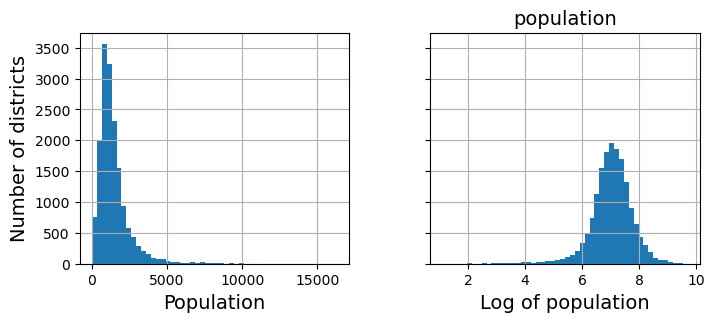

In [54]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
log_pop.hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

### 비율 변환

두 개의 특성 사이의 비율을 계산하여 다음 새로운 특성 세 개를 생성할 예정이다.

- 침실 비율: `housing['total_bedrooms'] / housing['total_rooms']`
- 가구당 방 수: `housing['total_bedrooms'] / housing['households']`
- 가구당 평균 가구원수: `housing['population'] / housing['households']`

비율 변환 또한 앞서 설명한 `FunctionTransformer` 변환기를 활용하며, 
아래 코드가 간단한 사용법을 보여준다.

- `sample_array`: (2, 2) 모양의 어레이
- `ratio_transformer`: 0번 열을 1번 열로 나눈값으로 구성된 어레이로 변환하는 변환기

In [55]:
sample_array = np.array([[1., 2.],
                         [3., 4.]])

In [56]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
transformed_array =ratio_transformer.transform(sample_array)

In [57]:
transformed_array

array([[0.5 ],
       [0.75]])

### 사용자 정의 변환기

훈련셋 준비 과정에서 경우에 따라 사용자가 직접 변환기를 구현해야할 필요가 있다.
여기서는 훈련셋에 포함된 구역들의 위도와 경도 정보를 이용하여 서로 가깝게 위치한 구역들로 묶어
총 10개의 군집<font size='2'>cluster</font>으로 구분하는 변환기를
직접 정의하여 활용한다.

In [58]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

아래 코드는 구역의 위도와 경도 정보를 이용하여 10개의 군집을 형성한다.

- `transform()` 메서드: 각 샘플과 10개의 군집의 중심<font size='2'>centroid</font> 사이의 유사도 점수를 계산한다.
- 구역별로 계산된 10개의 유사도 점수는 새로운 10개의 특성으로 훈련셋(입력 데이터셋)에 추가될 예정이다.

In [59]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

처음 3개 샘플과 각 군집의 중심에 대한 유사도 점수는 다음과 같다.
예를 들어 첫째 샘플의 경우 7번 인덱스의 값이 0.98로 가장 큰데,
이는 첫째 샘플이 8번째 군집의 중심와 가장 유사함(위도와 경도 기준)을 의미한다.

In [60]:
similarities[:3].round(2)

array([[0.46, 0.  , 0.08, 0.  , 0.  , 0.  , 0.  , 0.98, 0.  , 0.  ],
       [0.  , 0.96, 0.  , 0.03, 0.04, 0.  , 0.  , 0.  , 0.11, 0.35],
       [0.34, 0.  , 0.45, 0.  , 0.  , 0.  , 0.01, 0.73, 0.  , 0.  ]])

아래 그래프는 10개 군집의 중심과 각 구역의 위도, 경도 정보를 활용한 산점도이다.

- &#128473; 표시는 각 군집의 중심, 즉 각 군집의 중심 구역을 표시한다.
- 색상은 구역이 속한 군집의 중심과의 유사도를 가리킨다. 
    빨강색으로 표시된 구역이 해당 구역이 속한 군집의 중심과의 유사도(위도와 경도 기준)가 크다.
- 점의 크기는 구역 인구에 비례한다.

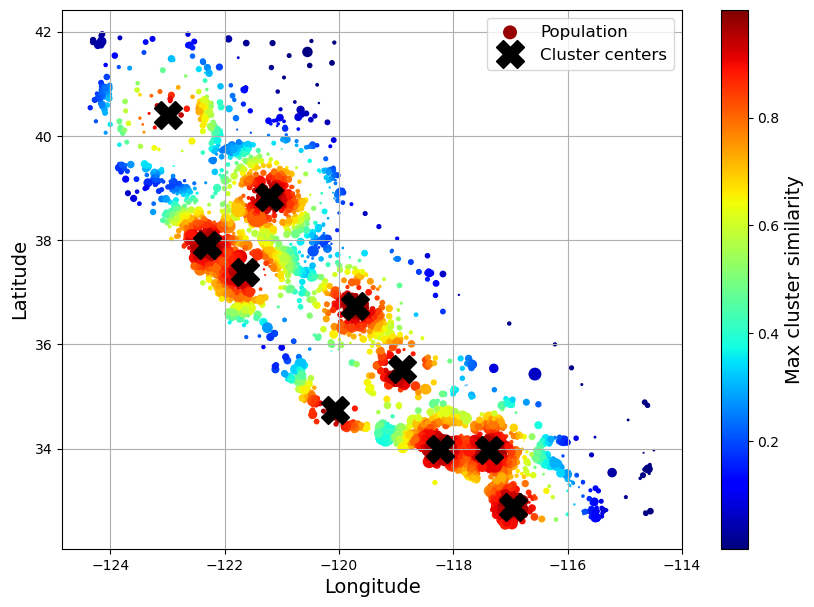

In [ ]:
# extra code – this cell generates Figure 2–19

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})

# 점 색깔 지정용 특성
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

# 위도, 경도 활용 산점도
# 점 크기는 인구에 비례, 점 색깔은 군집의 중심과의 유사도에 비례
housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))

# 군집의 중심: X 표시
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")

# 범례 표시
plt.legend(loc="upper right")

plt.show()

## 파이프라인

사이킷런에서 제공하는 파이프라인 관련 주요 API는 다음과 같다.

- `Pipeline` 클래스
- `make_pipeline()` 함수
- `ColumnTransformer` 클래스
- `make_column_selector()` 함수
- `make_column_transformer()` 함수

**주의 사항**

여기서는 먼저 언급된 파이프라인 관련 주요 API 활용법을 소개한다.
그런 다음 소개된 API를 조합해서 실제 캘리포니아 주택 가격 데이터셋의 변환에 사용되는 파이프라인은 지정한다.

### `Pipeline` 클래스

파이프라인으로 정의된 추정기가 변환기인지, 예측기인지 여부는
마지막 추정기에 의해 결정된다.
즉, 마지막 추정기가 변환기인지, 예측기인지에 따라
해당 파이프라인이 변환기 또는 예측기가 된다.
`num_pipeline`를 구성하는 마지막 추정기가 변환기이기에
생성된 파이프라인 역시 변환기가 된다.

파이프라인을 호출하면 마지막 추정기 이전까지의 변환기에 대해서는
`fit_transform()` 메소드가 연속적으로 호출된다.
따라서 파이프라인에 포함된 마지막 추정기를 제외한 모든 추정기는 변환기 이어야 한다.

일단 여기서는 변환기 파이프라인만 활용하며,
이후 머신러닝 모델을 구현할 때 예측기를 마지막 추정기로 지정하는
파이프라인을 이용한다.

**수치형 특성 변환 기본 파이프라인**

In [62]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

### `make_pipeline()` 함수

`make_pipeline()` 함수를 이용할 수도 있다.
단, 각 추정기의 이름은 자동으로 생성된다.

In [63]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

파이프라인 활용법은 변환기/예측기 활용법과 동일하다.

- `fit_transform()` 메서드를 호출하면 파이프라인에 포함된 변환기 각각에 대해 
    `fit_transform()` 메서드가 연속적으로 호출된다.

In [64]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [65]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)

In [66]:
df_housing_num_prepared.head(2)  # extra code

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942


**파이프라인 구조**

생성된 파이프라인의 구조를 그래프로 확인할 수 있다.

In [67]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

생성된 파이프라인의 구조를 파이프라인 객체의 속성으로도 확인할 수 있다.

In [68]:
num_pipeline.steps

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

마치 리스트처럼 인덱싱을 사용하면 파이프라인에 포함된
변환기/예측기를 하나씩 지정할 수도 있다.

In [69]:
num_pipeline[1]

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [70]:
num_pipeline[:-1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has 

변화기의 지정된 이름을 이용한 인덱싱도 가능하다.

In [71]:
num_pipeline.named_steps

{'simpleimputer': SimpleImputer(strategy='median'),
 'standardscaler': StandardScaler()}

In [72]:
num_pipeline.named_steps["simpleimputer"]

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


파이프라인에 포함된 변환기의 속성도 직접 지정할 수도 있다.
아래 코드는 표준화 변환기의 결측치 처리 전략을 중앙값을
사용하는 방식으로 지정한다.

In [73]:
num_pipeline.set_params(simpleimputer__strategy="median")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

### `ColumnTransformer` 클래스

특성별로 파이프라인을 지정할 수 있다.

In [74]:
from sklearn.compose import ColumnTransformer

# 수치형 특성 리스트 지정
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
# 범주형 특성 리스트 지정
cat_attribs = ["ocean_proximity"]

# 범주형 특성 변환 파이프라인
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

# 전체 특성 변환기
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

**`make_column_selector()` 함수**

파이프라인에 포함되는 각 변환기를 적용할 특성을 일일이 나열하는 일이 어려울 수 있다.
이때 지정된 자료형을 사용하는 특성들만을 선택해주는 `make_column_selector()` 함수를 
유용하게 활용할 수 있다.

- `make_column_selector(dtype_include=np.number)`: 수치형 특성 모두 선택
- `make_column_selector(dtype_include=object)`: 범주형 특성 모두 선택

따라서 위 `preprocessing` 변환기를 아래와 같이 정의할 수 있다.

```python
preprocessing = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)
])
```

### `make_column_transformer` 클래스

`make_column_transformer()` 함수를 이용하여 `ColumnTransformer` 변환기를
생성할 수도 있다.
단, 각 변환기의 이름은 자동으로 생성된다.

In [75]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

### 캘리포니아 데이터셋 변환 파이프라인

`ColumnTransformer` 클래스와 `Pipeline` 클래스를 이용하여
캘리포니아 주택 가격 데이터의 입력 데이터셋을 한꺼번에 변환하는 
파이프라인 변환기를 아래 코드에서 정의된 네 개의 파이프라인을 이용하여 구현한다.

In [ ]:
# 파이프라인 1: 두 수치형 특성의 비율을 계산하는 사용자 정의 변환기
def column_ratio(X):
    return X[:, [0]] / X[:, [1]] # 1번 특성에 대한 0번 특성의 비율율

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]  # 새로 생성되는 특성값들의 특성명

ratio_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(column_ratio, feature_names_out=ratio_name),
    StandardScaler())

# 파이프라인 2: 여러 수치형 특성에 로그 변환을 적용하는 사용자 정의 변환기
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

# 파이프라인 3: 위도와 경도를 활용하여 군집의 중심과의 유사도를 계산하는 사용자 정의 변환기
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

# 파이프라인 4: 기타 특성에 적용될 기본 수치형 특성 변환기
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

**종합**

앞서 언급된 모든 변환기를 특성별로 적용하는 변환기를
`ColumnTransformer` 클래스를 이용하여 정의한다.

`remainder=default_num_pipeline`는
그때까지 언급되지 않은 나머지 특성들을 처리하는 변환기를
키워드 인자로 지정한다.
`remainder` 매개변수의 키워드 인자로 나머지 특성을 삭제하는 것을 지정하는 
`drop` 이 기본값이며, 그 이외에 `passthrough`는 나머지 특성은 
변환하지 않고 그대로 두어야 함을 의미한다.

아래 코드에서는 마지막으로 남은 '주택 중위연령'을 가리키는 `housing_median_age` 특성에
기본 변환기를 적용하도록 지정한다.

In [77]:
preprocessing = ColumnTransformer([
        ("bedrooms", ratio_pipeline, ["total_bedrooms", "total_rooms"]),
        ("rooms_per_house", ratio_pipeline, ["total_rooms", "households"]),
        ("people_per_house", ratio_pipeline, ["population", "households"]),
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("geo", cluster_simil, ["latitude", "longitude"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    ],
    remainder=default_num_pipeline)  # 남은 특성 하나: housing_median_age

모든 파이프라인 변환기의 사용법은 동일하다.
아래 코드는 `housing` 훈련셋을 특성별로 지정된 변환을 실행한다.
반환값이 넘파이 어레이임에 주의한다.

In [78]:
housing_prepared = preprocessing.fit_transform(housing)

In [79]:
housing_prepared

array([[ 1.84662439, -0.86602737, -0.33020372, ...,  1.        ,
         0.        ,  1.86111875],
       [-0.5081207 ,  0.0245495 , -0.25361631, ...,  0.        ,
         0.        ,  0.90762971],
       [-0.20215476, -0.04119332, -0.05104091, ...,  0.        ,
         0.        ,  0.35142777],
       ...,
       [-0.24249175, -0.10998748,  0.15854151, ...,  0.        ,
         1.        , -1.23772062],
       [ 0.25977479, -0.36093745, -0.21033248, ...,  0.        ,
         0.        ,  0.66925745],
       [ 3.61270996, -1.32397227,  0.04958379, ...,  0.        ,
         1.        ,  1.22545939]], shape=(16512, 24))

특성이 총 24개로 늘었으며,
특성별 이름은 변환기의 `get_feature_names_out()` 메서드로 확인한다.

- 비율 변환기 적용: 3개의 새로운 특성 추가.
- 위도-경도 군집 특성: 10개의 특성으로 변환. 위도와 경도 2개의 특성 대신 10개 특성 새로 추가.
- 해안 근접도 더미 특성: 5개로 변환. 기존 해안 근접도 특성 제거 후 5개 더미 특성 추가.
- 나머지 특성: 1개 (중위 주택연령) 변환. 특성수는 그대로 유지됨

In [80]:
housing_prepared.shape

(16512, 24)

In [81]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age'], dtype=object)

In [82]:
housing_prepared_df = pd.DataFrame(housing_prepared,
                                   columns=preprocessing.get_feature_names_out(),
                                   index=housing.index)
housing_prepared_df.head()

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 6 similarity,geo__Cluster 7 similarity,geo__Cluster 8 similarity,geo__Cluster 9 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
13096,1.846624,-0.866027,-0.330204,1.324114,0.637892,0.456906,1.310369,-1.071522,4.581829e-01,1.241847e-14,...,8.489216e-04,9.770322e-01,2.382191e-08,3.819126e-18,0.0,0.0,0.0,1.0,0.0,1.861119
14973,-0.508121,0.024550,-0.253616,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,6.511495e-10,9.579596e-01,...,5.614049e-27,1.260964e-13,1.103491e-01,3.547610e-01,1.0,0.0,0.0,0.0,0.0,0.907630
3785,-0.202155,-0.041193,-0.051041,-0.925266,-0.859927,-0.941997,-0.913030,-0.756981,3.432506e-01,4.261141e-15,...,5.641131e-03,7.303265e-01,2.508224e-08,2.669659e-18,0.0,1.0,0.0,0.0,0.0,0.351428
14689,-0.149006,-0.034858,-0.141475,0.952773,0.943475,0.670700,0.925373,-0.912253,2.244844e-15,2.704823e-01,...,5.913326e-35,5.201263e-20,1.712982e-03,8.874598e-01,0.0,1.0,0.0,0.0,0.0,-0.919891
20507,0.963208,-0.666554,-0.306148,1.437622,1.003590,0.719093,1.481464,0.034537,1.090228e-11,9.422206e-01,...,5.421817e-30,1.048030e-15,2.568824e-02,5.279506e-01,0.0,0.0,0.0,0.0,1.0,0.589800


In [83]:
housing_prepared_df.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   bedrooms__ratio                  16512 non-null  float64
 1   rooms_per_house__ratio           16512 non-null  float64
 2   people_per_house__ratio          16512 non-null  float64
 3   log__total_bedrooms              16512 non-null  float64
 4   log__total_rooms                 16512 non-null  float64
 5   log__population                  16512 non-null  float64
 6   log__households                  16512 non-null  float64
 7   log__median_income               16512 non-null  float64
 8   geo__Cluster 0 similarity        16512 non-null  float64
 9   geo__Cluster 1 similarity        16512 non-null  float64
 10  geo__Cluster 2 similarity        16512 non-null  float64
 11  geo__Cluster 3 similarity        16512 non-null  float64
 12  geo__Cluster 4 similarity     

## 모델 선택과 훈련

### 모델 훈련과 평가

In [120]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Let's try the full preprocessing pipeline on a few training instances:

In [121]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

array([246000., 372700., 135700.,  91400., 330900.])

Compare against the actual values:

In [122]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [123]:
# extra code – computes the error ratios discussed in the book
error_ratios = housing_predictions[:5].round(-2) / housing_labels.iloc[:5].values - 1
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-46.3%, -23.0%, 33.4%, -4.9%, -8.5%


In [124]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68972.88910758478

In [125]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

,steps,"[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [126]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

### 교차 검증

In [127]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)

In [128]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66573.734600
std       1103.402323
min      64607.896046
25%      66204.731788
50%      66388.272499
75%      66826.257468
max      68532.210664
dtype: float64

In [129]:
# extra code – computes the error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     70003.404818
std       4182.188328
min      65504.765753
25%      68172.065831
50%      68743.995249
75%      70344.943988
max      81037.863741
dtype: float64

**Warning:** the following cell may take a few minutes to run:

In [130]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing,
                           RandomForestRegressor(random_state=42))
forest_rmses = -cross_val_score(forest_reg, housing, housing_labels,
                                scoring="neg_root_mean_squared_error", cv=10)

In [131]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47038.092799
std       1021.491757
min      45495.976649
25%      46510.418013
50%      47118.719249
75%      47480.519175
max      49140.832210
dtype: float64

Let's compare this RMSE measured using cross-validation (the "validation error") with the RMSE measured on the training set (the "training error"):

In [132]:
forest_reg.fit(housing, housing_labels)
housing_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
forest_rmse

17551.212250087698

The training error is much lower than the validation error, which usually means that the model has overfit the training set. Another possible explanation may be that there's a mismatch between the training data and the validation data, but it's not the case here, since both came from the same dataset that we shuffled and split in two parts.

## 모델 미세 조정

### 그리드 탐색

**Warning:** the following cell may take a few minutes to run:

In [133]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42)),
])
param_grid = [
    {'preprocessing__geo__n_clusters': [5, 8, 10],
     'random_forest__max_features': [4, 6, 8]},
    {'preprocessing__geo__n_clusters': [10, 15],
     'random_forest__max_features': [6, 8, 10]},
]
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"


You can get the full list of hyperparameters available for tuning by looking at `full_pipeline.get_params().keys()`:

In [134]:
# extra code – shows part of the output of get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

The best hyperparameter combination found:

In [135]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [136]:
grid_search.best_estimator_

,steps,"[('preprocessing', ...), ('random_forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Let's look at the score of each hyperparameter combination tested during the grid search:

In [137]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,42725,43708,44335,43590
13,15,8,43486,43820,44900,44069
6,10,4,43798,44036,44961,44265
9,10,6,43710,44163,44967,44280
7,10,6,43710,44163,44967,44280


### 랜덤 탐색

In [138]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

Try 30 (`n_iter` × `cv`) random combinations of hyperparameters:

**Warning:** the following cell may take a few minutes to run:

In [139]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters': randint(low=3, high=50),
                  'random_forest__max_features': randint(low=2, high=20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing, housing_labels)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'preprocessing__geo__n_clusters': <scipy.stats....x7f5cb0c2cb90>, 'random_forest__max_features': <scipy.stats....x7f5cb0adb290>}"
,n_iter,10
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [140]:
# extra code – displays the random search results
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41342,42242,43057,42214
8,32,7,41825,42275,43241,42447
0,41,16,42238,42938,43354,42843
5,42,4,41869,43362,43664,42965
2,23,8,42490,42928,43718,43046


**Bonus section: how to choose the sampling distribution for a hyperparameter**

* `scipy.stats.randint(a, b+1)`: for hyperparameters with _discrete_ values that range from a to b, and all values in that range seem equally likely.
* `scipy.stats.uniform(a, b)`: this is very similar, but for _continuous_ hyperparameters.
* `scipy.stats.geom(1 / scale)`: for discrete values, when you want to sample roughly in a given scale. E.g., with scale=1000 most samples will be in this ballpark, but ~10% of all samples will be <100 and ~10% will be >2300.
* `scipy.stats.expon(scale)`: this is the continuous equivalent of `geom`. Just set `scale` to the most likely value.
* `scipy.stats.loguniform(a, b)`: when you have almost no idea what the optimal hyperparameter value's scale is. If you set a=0.01 and b=100, then you're just as likely to sample a value between 0.01 and 0.1 as a value between 10 and 100.


Here are plots of the probability mass functions (for discrete variables), and probability density functions (for continuous variables) for `randint()`, `uniform()`, `geom()` and `expon()`:

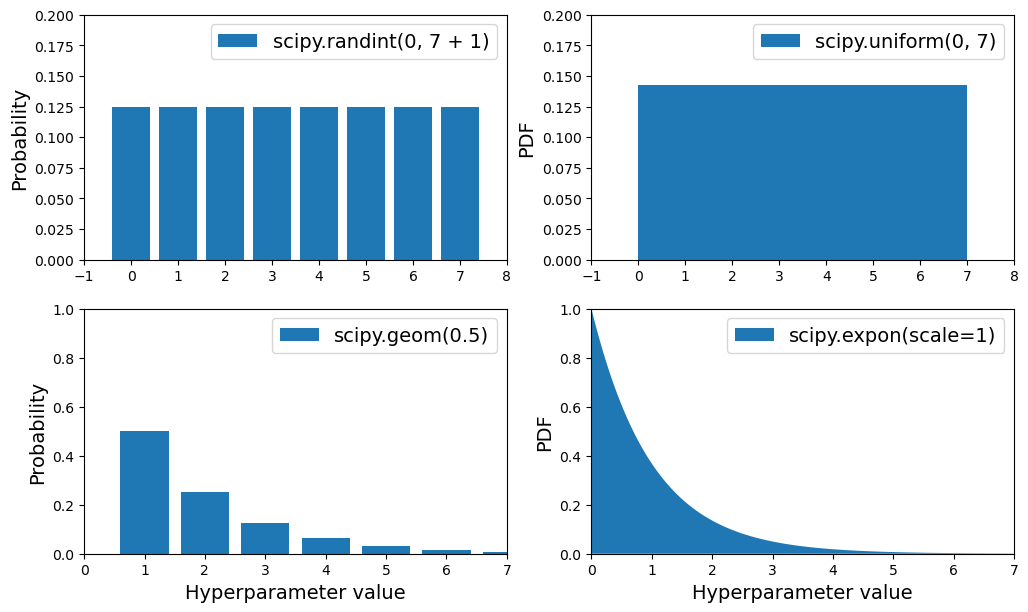

In [141]:
# extra code – plots a few distributions you can use in randomized search

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

Here are the PDF for `expon()` and `loguniform()` (left column), as well as the PDF of log(X) (right column). The right column shows the distribution of hyperparameter _scales_. You can see that `expon()` favors hyperparameters with roughly the desired scale, with a longer tail towards the smaller scales. But `loguniform()` does not favor any scale, they are all equally likely:

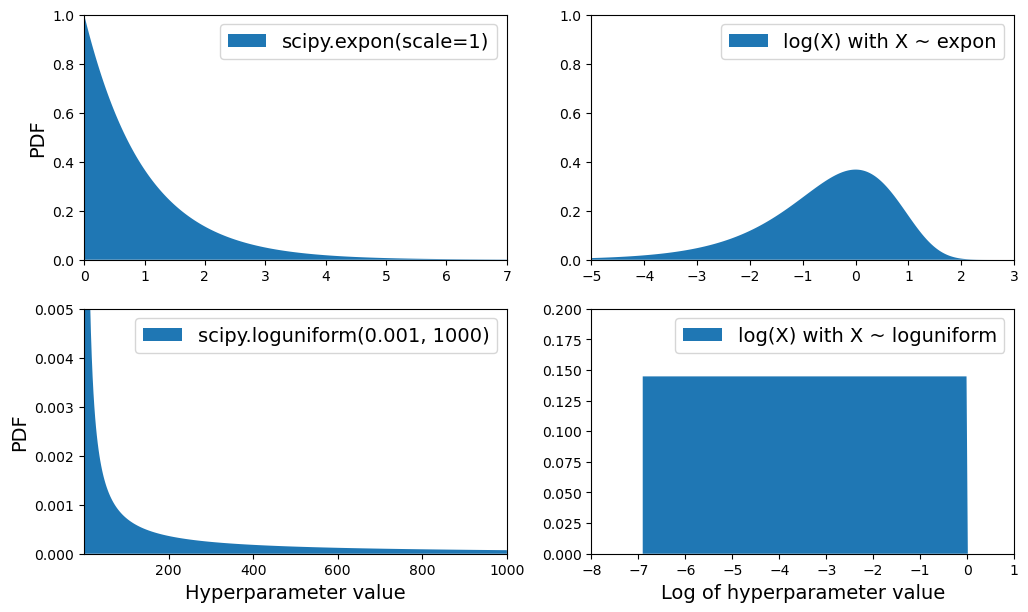

In [142]:
# extra code – shows the difference between expon and loguniform

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib,
                 label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib,
                 label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib,
                 label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib,
                 label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

## 최적 모델 활용 및 평가

In [ ]:
final_model = rnd_search.best_estimator_  # includes preprocessing

### 테스트셋 활용

In [145]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

final_predictions = final_model.predict(X_test)

final_rmse = root_mean_squared_error(y_test, final_predictions)
print(final_rmse)

41445.533268606625


We can compute a 95% confidence interval for the test RMSE using SciPy's `bootstrap()` function:

In [146]:
from scipy.stats import bootstrap

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
boot_result = bootstrap([squared_errors], rmse, confidence_level=confidence,
                        random_state=42)
rmse_lower, rmse_upper = boot_result.confidence_interval

In [147]:
print(f"95% CI for RMSE: ({rmse_lower:.4f}, {rmse_upper:.4f})")

95% CI for RMSE: (39520.9572, 43701.7681)


### 모델 기타 활용법

In [ ]:
feature_importances = final_model["random_forest"].feature_importances_
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
       reverse=True)

[(np.float64(0.18599734460509476), 'log__median_income'),
 (np.float64(0.07338850855844489), 'cat__ocean_proximity_INLAND'),
 (np.float64(0.06556941990883976), 'bedrooms__ratio'),
 (np.float64(0.053648710076725316), 'rooms_per_house__ratio'),
 (np.float64(0.04598870861894749), 'people_per_house__ratio'),
 (np.float64(0.04175269214442519), 'geo__Cluster 30 similarity'),
 (np.float64(0.025976797232869678), 'geo__Cluster 25 similarity'),
 (np.float64(0.023595895886342255), 'geo__Cluster 36 similarity'),
 (np.float64(0.02021056221732893), 'geo__Cluster 9 similarity'),
 (np.float64(0.01860691707666145), 'geo__Cluster 34 similarity'),
 (np.float64(0.018137988374628867), 'geo__Cluster 37 similarity'),
 (np.float64(0.01740435316632675), 'geo__Cluster 18 similarity'),
 (np.float64(0.016778386143844894), 'geo__Cluster 1 similarity'),
 (np.float64(0.015459009666188978), 'geo__Cluster 7 similarity'),
 (np.float64(0.015325731028175924), 'geo__Cluster 32 similarity'),
 (np.float64(0.0150737720150383

### 모델 저장

Save the final model:

In [144]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

Now you can deploy this model to production. For example, the following code could be a script that would run in production:

In [145]:
import joblib

# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

final_model_reloaded = joblib.load("my_california_housing_model.pkl")

new_data = housing.iloc[:5]  # pretend these are new districts
predictions = final_model_reloaded.predict(new_data)

In [146]:
predictions

array([441046.12, 454713.09, 104832.  , 101316.  , 336181.05])